In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import cv2

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

2026-05-31 22:51:18.008636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780267878.195953      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780267878.252739      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780267878.696137      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780267878.696178      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780267878.696181      59 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [4]:
import os

print("Notebook Working")
print(os.listdir('/kaggle/input'))

Notebook Working
['models', 'datasets', 'notebooks']


In [5]:
print(os.listdir('/kaggle/input/datasets'))

['msambare']


In [6]:
print(os.listdir('/kaggle/input/datasets/msambare'))

['fer2013']


In [7]:
print(os.listdir('/kaggle/input/datasets/msambare/fer2013'))

['test', 'train']


In [8]:
train_path = "/kaggle/input/datasets/msambare/fer2013/train"

test_path = "/kaggle/input/datasets/msambare/fer2013/test"

In [9]:
classes = os.listdir(train_path)

print(classes)

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [10]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
train_path = "/kaggle/input/datasets/msambare/fer2013/train"
test_path = "/kaggle/input/datasets/msambare/fer2013/test"

In [12]:
classes = os.listdir(train_path)
print("Classes:", classes)

Classes: ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [13]:
print(os.listdir('/kaggle/input'))

['models', 'datasets', 'notebooks']


In [14]:
import os

print(os.listdir('/kaggle/input'))

['models', 'datasets', 'notebooks']


In [15]:
import os

print(os.listdir('/kaggle/input/datasets'))

['msambare']


In [16]:
print(os.listdir('/kaggle/input/datasets/msambare'))

['fer2013']


In [17]:
train_path = "/kaggle/input/datasets/msambare/fer2013/train"
test_path = "/kaggle/input/datasets/msambare/fer2013/test"

In [18]:
classes = os.listdir(train_path)

print(classes)

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [19]:
for category in classes:
    
    folder = os.path.join(train_path, category)
    
    count = len(os.listdir(folder))
    
    print(category, "=", count)

surprise = 3171
fear = 4097
angry = 3995
neutral = 4965
sad = 4830
disgust = 436
happy = 7215


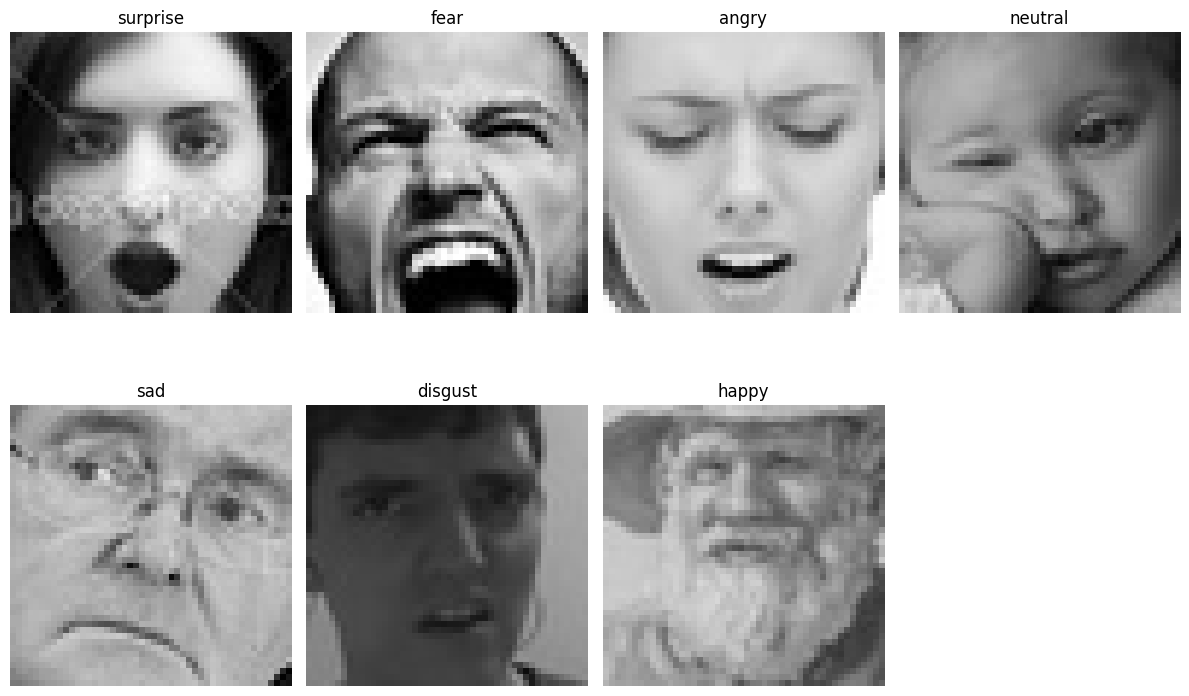

In [20]:
plt.figure(figsize=(12,8))

for i, category in enumerate(classes):
    
    folder = os.path.join(train_path, category)
    
    image_name = os.listdir(folder)[0]
    
    image_path = os.path.join(folder, image_name)
    
    image = cv2.imread(image_path)
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(image)
    
    plt.title(category)
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
train_datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    rotation_range=20,
    
    zoom_range=0.2,
    
    horizontal_flip=True,
    
    validation_split=0.2
)

In [22]:
validation_datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    validation_split=0.2
)

In [23]:
train_generator = train_datagen.flow_from_directory(
    
    train_path,
    
    target_size=(48,48),
    
    batch_size=32,
    
    color_mode="grayscale",
    
    class_mode='categorical',
    
    subset='training'
)

Found 22968 images belonging to 7 classes.


In [24]:
color_mode="grayscale"

In [25]:
validation_generator = validation_datagen.flow_from_directory(
    
    train_path,
    
    target_size=(48,48),
    
    batch_size=32,
    
    color_mode="grayscale",
    
    class_mode='categorical',
    
    subset='validation'
)

Found 5741 images belonging to 7 classes.


In [26]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    
    test_path,
    
    target_size=(48,48),
    
    batch_size=32,
    
    color_mode="grayscale",
    
    class_mode='categorical',
    
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [27]:
cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(48,48,1)
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(7, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780267914.613528      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cnn_model.compile(
    
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [29]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/models
/kaggle/input/models/nischitha2003
/kaggle/input/models/nischitha2003/ha
/kaggle/input/models/nischitha2003/ha/other
/kaggle/input/models/nischitha2003/ha/other/default
/kaggle/input/models/nischitha2003/ha/other/default/1
/kaggle/input/datasets
/kaggle/input/datasets/msambare
/kaggle/input/datasets/msambare/fer2013
/kaggle/input/datasets/msambare/fer2013/test
/kaggle/input/datasets/msambare/fer2013/test/surprise
/kaggle/input/datasets/msambare/fer2013/test/fear
/kaggle/input/datasets/msambare/fer2013/test/angry
/kaggle/input/datasets/msambare/fer2013/test/neutral
/kaggle/input/datasets/msambare/fer2013/test/sad
/kaggle/input/datasets/msambare/fer2013/test/disgust
/kaggle/input/datasets/msambare/fer2013/test/happy
/kaggle/input/datasets/msambare/fer2013/train
/kaggle/input/datasets/msambare/fer2013/train/surprise
/kaggle/input/datasets/msambare/fer2013/train/fear
/kaggle/input/datasets/msambare/fer2013/train/angry
/kaggle/input/datasets/msambare/fer20

In [30]:
import os

train_path = "/kaggle/input/datasets/msambare/fer2013/train"
test_path = "/kaggle/input/datasets/msambare/fer2013/test"

print("Train exists:", os.path.exists(train_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Test exists: True


In [31]:
import os

classes = os.listdir(train_path)

print("Classes:", classes)

Classes: ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


In [33]:
print(type(train_generator))
print(type(validation_generator))
print(type(cnn_model))

<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>
<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>
<class 'keras.src.models.sequential.Sequential'>


In [34]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15


I0000 00:00:1780267937.711476     130 service.cc:152] XLA service 0x7bc650005620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780267937.711530     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780267938.094280     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/718 ━━━━━━━━━━━━━━━━━━━━ 51s 71ms/step - accuracy: 0.1632 - loss: 1.9516

I0000 00:00:1780267940.691113     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


718/718 ━━━━━━━━━━━━━━━━━━━━ 134s 181ms/step - accuracy: 0.2864 - loss: 1.7524 - val_accuracy: 0.3714 - val_loss: 1.5977
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.4070 - loss: 1.5303 - val_accuracy: 0.4323 - val_loss: 1.4578
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.4580 - loss: 1.4177 - val_accuracy: 0.4659 - val_loss: 1.3851
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.4830 - loss: 1.3471 - val_accuracy: 0.4853 - val_loss: 1.3358
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.5093 - loss: 1.2883 - val_accuracy: 0.5138 - val_loss: 1.2640
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5310 - loss: 1.2379 - val_accuracy: 0.5267 - val_loss: 1.2546
Epoch 7/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5484 - loss: 1.1909 - val_accuracy: 0.5388 - val_loss: 1.2238
Epoch 8/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5627 - loss: 1.1486 - val_accur

In [35]:
print("cnn_model" in globals())

True


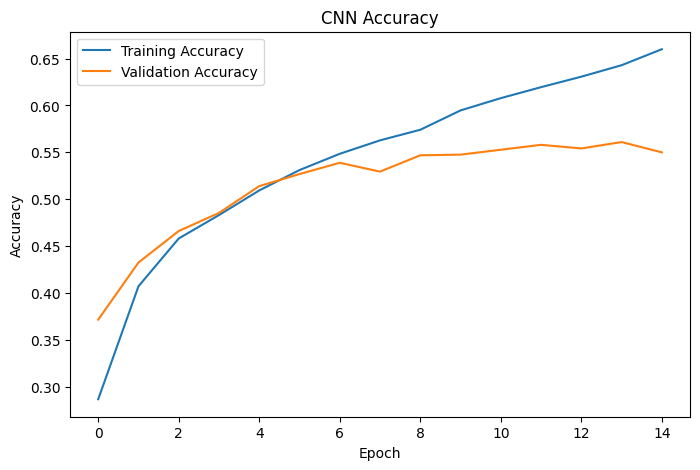

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('accuracy_curve.png')
plt.show()

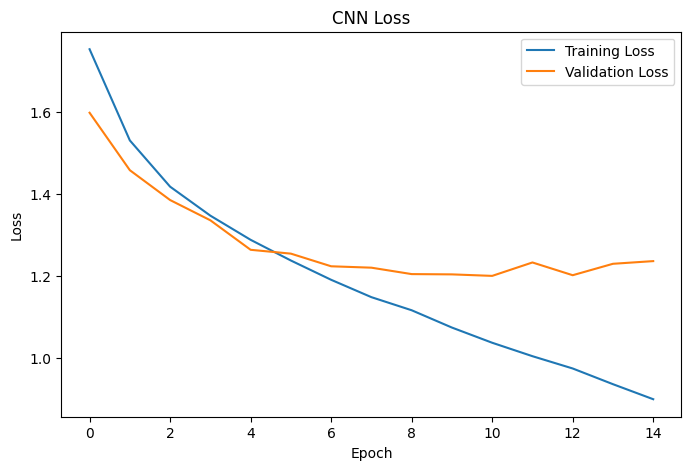

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('loss_curve.png')
plt.show()

In [38]:
print(test_path)

/kaggle/input/datasets/msambare/fer2013/test


In [39]:
loss, accuracy = cnn_model.evaluate(test_generator)

print("CNN Test Loss:", loss)
print("CNN Test Accuracy:", accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 37s 165ms/step - accuracy: 0.5563 - loss: 1.2277
CNN Test Loss: 1.2277050018310547
CNN Test Accuracy: 0.5562831163406372


In [40]:
predictions = cnn_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step


In [41]:
print(type(cnn_model))

<class 'keras.src.models.sequential.Sequential'>


In [42]:
train_path = "/kaggle/input/datasets/msambare/fer2013/train"
test_path = "/kaggle/input/datasets/msambare/fer2013/test"

In [43]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [44]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(7,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.2935 - loss: 1.7372 - val_accuracy: 0.4015 - val_loss: 1.5633
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.4103 - loss: 1.5126 - val_accuracy: 0.4438 - val_loss: 1.4276
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4666 - loss: 1.3952 - val_accuracy: 0.4910 - val_loss: 1.3301
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.4951 - loss: 1.3239 - val_accuracy: 0.5084 - val_loss: 1.2864
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5155 - loss: 1.2718 - val_accuracy: 0.5299 - val_loss: 1.2284
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5314 - loss: 1.2248 - val_accuracy: 0.5260 - val_loss: 1.2603
Epoch 7/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5531 - loss: 1.1816 - val_accuracy: 0.5365 - val_loss: 1.2318
Epoch 8/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5661 - loss: 1.1420 - 

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.2860 - loss: 1.7567 - val_accuracy: 0.3440 - val_loss: 1.6094
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.4043 - loss: 1.5353 - val_accuracy: 0.4586 - val_loss: 1.4221
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4506 - loss: 1.4232 - val_accuracy: 0.4926 - val_loss: 1.3479
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.4825 - loss: 1.3569 - val_accuracy: 0.5004 - val_loss: 1.2981
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5059 - loss: 1.3020 - val_accuracy: 0.5043 - val_loss: 1.2822
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.5238 - loss: 1.2525 - val_accuracy: 0.5276 - val_loss: 1.2444
Epoch 7/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.5411 - loss: 1.2069 - val_accuracy: 0.5370 - val_loss: 1.2172
Epoch 8/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5589 - loss: 1.1640 - 

In [48]:
loss, accuracy = cnn_model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5483 - loss: 1.2225
Test Loss: 1.2225114107131958
Test Accuracy: 0.5483421683311462


In [49]:
import numpy as np

predictions = cnn_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step


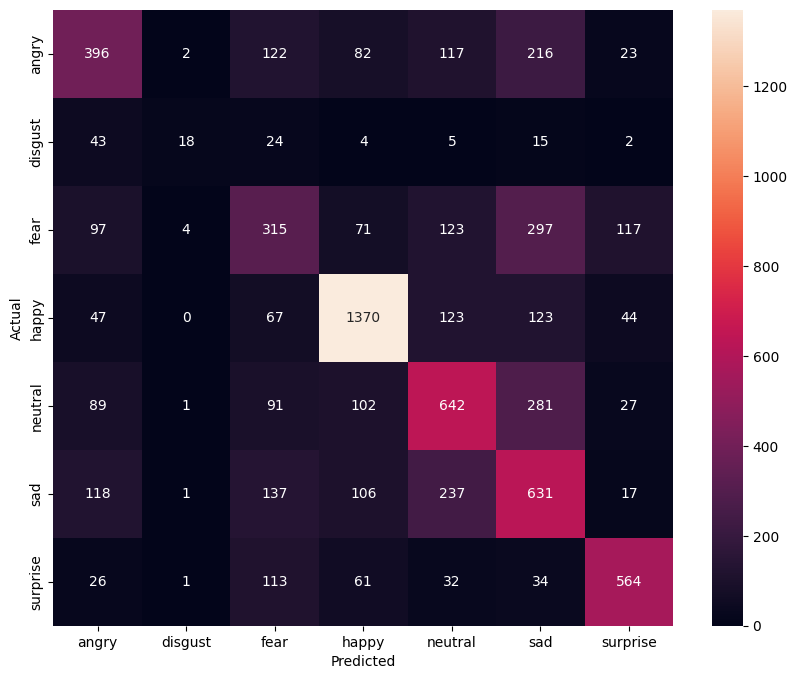

In [50]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

       angry       0.49      0.41      0.45       958
     disgust       0.67      0.16      0.26       111
        fear       0.36      0.31      0.33      1024
       happy       0.76      0.77      0.77      1774
     neutral       0.50      0.52      0.51      1233
         sad       0.40      0.51      0.44      1247
    surprise       0.71      0.68      0.69       831

    accuracy                           0.55      7178
   macro avg       0.55      0.48      0.49      7178
weighted avg       0.55      0.55      0.55      7178



In [52]:
cnn_model.save("cnn_facial_expression_model.h5")

print("Model saved successfully")

Model saved successfully


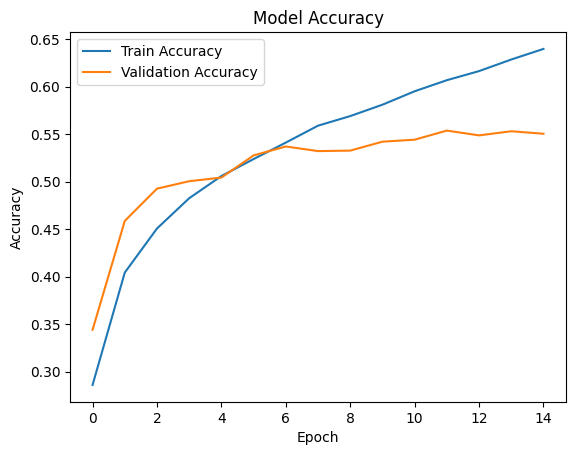

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

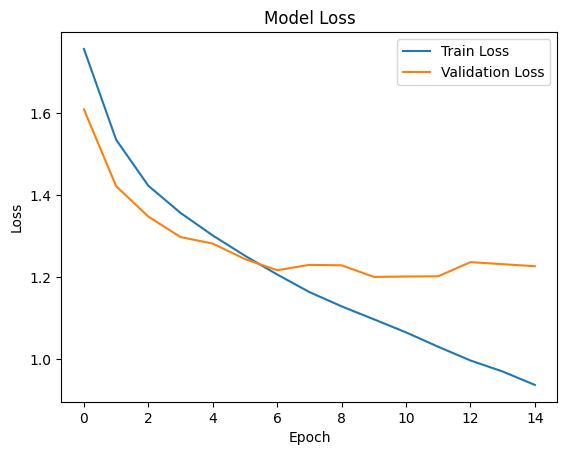

In [54]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

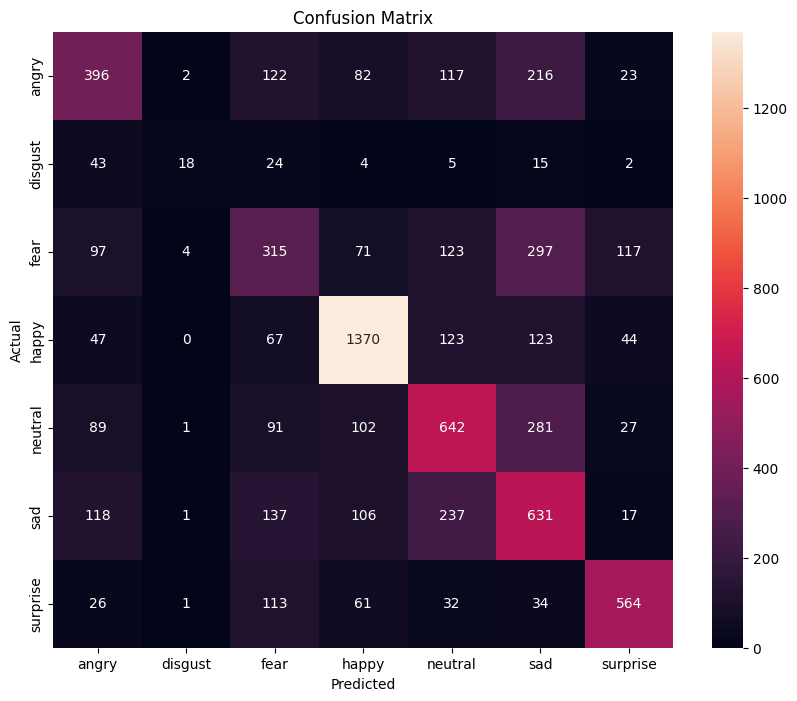

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [57]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator_rgb = train_datagen.flow_from_directory(
    train_path,
    target_size=(96,96),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

validation_generator_rgb = train_datagen.flow_from_directory(
    train_path,
    target_size=(96,96),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


In [58]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [59]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(7, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

In [60]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
history_transfer = transfer_model.fit(
    train_generator_rgb,
    validation_data=validation_generator_rgb,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 57s 65ms/step - accuracy: 0.3601 - loss: 1.6431 - val_accuracy: 0.4161 - val_loss: 1.4939
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.4108 - loss: 1.5208 - val_accuracy: 0.4468 - val_loss: 1.4417
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.4298 - loss: 1.4722 - val_accuracy: 0.4511 - val_loss: 1.4283
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.4424 - loss: 1.4411 - val_accuracy: 0.4557 - val_loss: 1.4062
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.4501 - loss: 1.4151 - val_accuracy: 0.4564 - val_loss: 1.4010
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.4621 - loss: 1.3866 - val_accuracy: 0.4734 - val_loss: 1.3900
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.4705 - loss: 1.3708 - val_accuracy: 0.4748 - val_loss: 1.3855
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.4783 - loss: 1.3480 - 

In [62]:
loss, accuracy = transfer_model.evaluate(validation_generator_rgb)

print("Transfer Learning Accuracy:", accuracy)

180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4792 - loss: 1.3775
Transfer Learning Accuracy: 0.4791848063468933


In [63]:
print("CNN Accuracy =", history.history['val_accuracy'][-1])
print("Transfer Learning Accuracy =", accuracy)

CNN Accuracy = 0.5504267811775208
Transfer Learning Accuracy = 0.4791848063468933


In [64]:
plt.savefig("accuracy.png")
plt.savefig("loss.png")
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [65]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if 'ha' in file.lower():
            print(os.path.join(root, file))

/kaggle/input/models/nischitha2003/ha/other/default/1/ha.jpeg


Image Shape: (183, 275, 3)


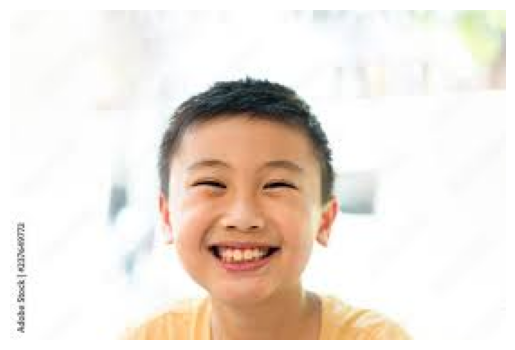

In [66]:
import cv2
import matplotlib.pyplot as plt

img_path = "/kaggle/input/models/nischitha2003/ha/other/default/1/ha.jpeg"

img = cv2.imread(img_path)

print("Image Shape:", img.shape)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [67]:
import cv2
import numpy as np

img_path = "/kaggle/input/models/nischitha2003/ha/other/default/1/ha.jpeg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (48,48))

img = img / 255.0

img = img.reshape(1,48,48,1)

prediction = cnn_model.predict(img)

classes = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise'
]

print("Predicted Emotion:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Predicted Emotion: happy


In [68]:
print('cnn_model' in globals())

True


In [69]:
print(cnn_model.input_shape)

(None, 48, 48, 1)


In [70]:
cnn_model.evaluate(test_generator)

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5483 - loss: 1.2225


[1.2225114107131958, 0.5483421683311462]

In [71]:
cnn_model.evaluate(test_generator)

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5483 - loss: 1.2225


[1.2225114107131958, 0.5483421683311462]